# 03 — Exploratory Data Analysis (EDA)

| Field | Detail |
|---|---|
| **Notebook** | `03_eda.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 3 of 7 |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *28/08/2026* |
| **Last updated** | *28/08/2026* |
| **Upstream dependency** | `02_preprocessing.ipynb` — reads its manifest and standardized audio, and checks its validation report before proceeding |
| **Downstream dependency** | `04a_feature_extraction_handcrafted.ipynb`, `04b_feature_extraction_raw_audio.ipynb`, `04c_asr_transcription.ipynb` |
| **Research proposal reference** | Section 5.1 (Voice Emotion Recognition) |

## Purpose

This notebook is written so that **anyone reading it — including someone with no prior exposure to this dataset or this project — can understand what the data looks like, where it comes from, and what its limitations are, without needing to consult any other document.**

It answers, with evidence rather than assumption, the questions a careful reviewer (or an examiner in a viva) will always ask about a dataset before trusting any model trained on it:

- *How much data is there, and is it balanced across the classes being predicted?*
- *Who is actually represented in this data (which languages, genders, speakers)?*
- *What does the raw audio actually look and sound like for each emotion?*
- *What structural issues (imbalance, speaker overlap, duration variance) need to be accounted for before training?*

This notebook does **not** modify the manifest or the audio — it is a read-only inspection step. Any issue found here (e.g. class imbalance) is *documented* here and *acted on* in the feature-extraction or model-training notebooks that follow.

## Objectives

1. Load and validate the manifest and preprocessing report produced by `02_preprocessing.ipynb`.
2. Give a plain-language introduction to each of the three source datasets (RAVDESS, TESS, SAVEE) for a reader with zero prior context.
3. Visualize class (emotion) distribution — overall, per data split, and per source dataset.
4. Visualize speaker and gender composition of the merged pool.
5. Visualize the duration distribution of the original (pre-standardization) audio.
6. Quantify and discuss class imbalance, and its implications for model training.
7. Check for speaker overlap across train/validation/test splits, and discuss what this means for how generalization results should be interpreted.
8. Visualize example waveforms, mel-spectrograms, and MFCCs for each emotion class, to build visual/auditory intuition for what the models will actually be learning from.
9. Summarize key findings and hand off clear, actionable notes to the feature-extraction notebooks.

## 0. Environment Setup

In [1]:
import sys
import json
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

print(f"Project root resolved to: {PROJECT_ROOT}")

Project root resolved to: C:\Users\thrit\Desktop\emotion-ai-companion-research


In [2]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "03_eda.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("eda")

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
logger.info("Figures will be saved to: %s", FIGURES_DIR)

2026-08-28 07:59:46,778 | INFO | Figures will be saved to: C:\Users\thrit\Desktop\emotion-ai-companion-research\reports\figures\h1_eda


## 1. Load & Validate Upstream Outputs

Before analyzing anything, this notebook confirms that `02_preprocessing.ipynb` completed successfully and passed its own validation checks. Running EDA on unverified data would risk drawing conclusions from a manifest that might contain a labeling bug.

In [3]:
preprocessing_report_path = PROJECT_ROOT / "reports" / "02_preprocessing_report.json"
if not preprocessing_report_path.exists():
    raise FileNotFoundError(
        f"{preprocessing_report_path} not found. Run 02_preprocessing.ipynb to completion first."
    )

with open(preprocessing_report_path) as f:
    preprocessing_report = json.load(f)

assert preprocessing_report["class_count_validation_passed"], (
    "02_preprocessing.ipynb reported a class-count validation failure. "
    "Do not proceed with EDA on unverified data — fix and re-run notebook 02 first."
)
assert preprocessing_report["checksum_verification_passed"], (
    "02_preprocessing.ipynb reported a checksum verification failure. "
    "Do not proceed — fix and re-run notebook 02 first."
)

logger.info("Upstream validation confirmed: class counts and checksums both passed.")
print("\u2705 Upstream preprocessing validated successfully. Proceeding with EDA.")

2026-08-28 08:00:00,957 | INFO | Upstream validation confirmed: class counts and checksums both passed.
✅ Upstream preprocessing validated successfully. Proceeding with EDA.


In [4]:
manifest_path = PROJECT_ROOT / preprocessing_report["manifest_path"]
manifest_df = pd.read_csv(manifest_path)

print(f"Loaded manifest: {manifest_path}")
print(f"Shape: {manifest_df.shape[0]} rows x {manifest_df.shape[1]} columns")
manifest_df.head()

Loaded manifest: C:\Users\thrit\Desktop\emotion-ai-companion-research\data\processed\h1_manifest.csv
Shape: 4068 rows x 9 columns


,original_path,standardized_path,source_dataset,speaker_id,gender,original_emotion_code,label,duration_sec_original,split
0,training\data\ravdess_raw\Actor_13\03-01-02-01...,data\processed\audio_standardized\ravdess\03-0...,ravdess,Actor_13,male,02,neutral,2.936271,train
1,training\data\tess_raw\TESS Toronto emotional ...,data\processed\audio_standardized\tess\YAF_dat...,tess,YAF (younger adult female),female,happy,happy,1.823011,train
2,training\data\tess_raw\TESS Toronto emotional ...,data\processed\audio_standardized\tess\OAF_rag...,tess,OAF (older adult female),female,sad,sad,2.853895,train
3,training\data\tess_raw\TESS Toronto emotional ...,data\processed\audio_standardized\tess\YAF_hus...,tess,YAF (younger adult female),female,happy,happy,1.971738,train
4,training\data\tess_raw\TESS Toronto emotional ...,data\processed\audio_standardized\tess\OAF_lat...,tess,OAF (older adult female),female,sad,sad,2.390186,train


## 2. What Is This Data? — Dataset Overview for a First-Time Reader

This project trains an emotion-recognition model on speech drawn from three separate, independently-recorded, publicly available research datasets. Each was created by a different research group, using different speakers, in different English-speaking accents. Merging them (see `02_preprocessing.ipynb`) gives more training data than any single one alone, at the cost of needing to reconcile their different labeling conventions and speaker demographics — both of which are made explicit below.

| Dataset | Full name | Speakers | Gender | Accent | Native emotions | Files retained here* |
|---|---|---|---|---|---|---|
| **RAVDESS** | Ryerson Audio-Visual Database of Emotional Speech and Song | 24 professional actors | 12 male, 12 female | North American English | neutral, calm, happy, sad, angry, fearful, disgust, surprised | 1,248 |
| **TESS** | Toronto Emotional Speech Set | 2 actresses (ages 26 and 64) | Female only | Canadian English | angry, disgust, fear, happy, neutral, sad, pleasant surprise | 2,400 |
| **SAVEE** | Surrey Audio-Visual Expressed Emotion | 4 actors | Male only | British English | anger, disgust, fear, happiness, neutral, sadness, surprise | 420 |

*After excluding the "disgust" class (present in all three datasets but with no equivalent in this project's 6-class scheme) and, for RAVDESS, merging "calm" into "neutral" — see `02_preprocessing.ipynb`, Section 2, for the full rationale and citations.

**Why this matters for interpreting every result in this notebook and beyond:** TESS contributes *only* female speech and SAVEE contributes *only* male speech. Any class-balance or performance difference that correlates with gender could equally be a *dataset-of-origin* effect (different accent, recording equipment, speaking style) rather than a true gender effect — this ambiguity is a genuine limitation worth stating plainly in the thesis, not something a bigger model can fix.

## 3. Class (Emotion) Distribution

This is the single most important question to answer before training any classifier: **are all six emotions represented roughly equally?** If not, a model can achieve deceptively high accuracy simply by favoring the majority class, without actually learning to distinguish emotions well — this is why we check it visually before writing a single line of model code.

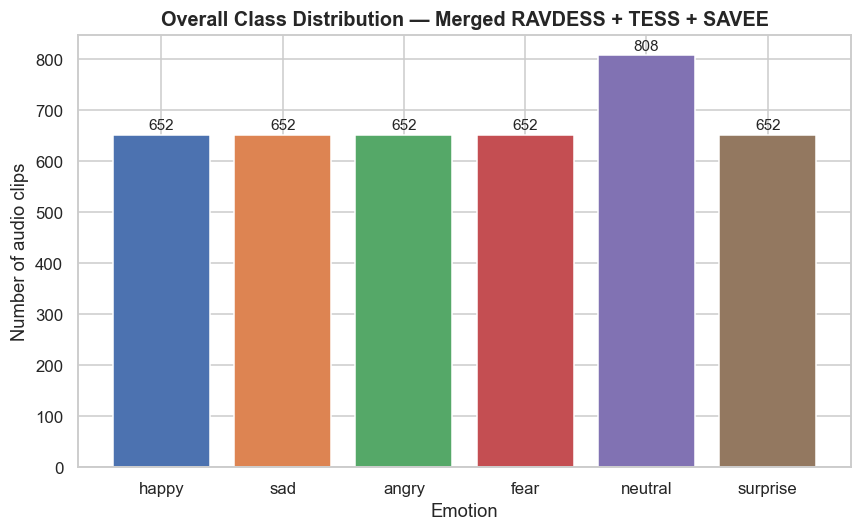

label
happy       652
sad         652
angry       652
fear        652
neutral     808
surprise    652
Name: count, dtype: int64

Most frequent class: neutral (808 clips)
Least frequent class: happy (652 clips)
Imbalance ratio (max/min): 1.24x


In [5]:
overall_counts = manifest_df["label"].value_counts().reindex(settings.emotion_labels)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(overall_counts.index, overall_counts.values, color=sns.color_palette("deep", len(overall_counts)))
ax.set_title("Overall Class Distribution — Merged RAVDESS + TESS + SAVEE", fontsize=13, weight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of audio clips")
for bar, count in zip(bars, overall_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, str(count), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_overall_class_distribution.png")
plt.show()

print(overall_counts)
print(f"\nMost frequent class: {overall_counts.idxmax()} ({overall_counts.max()} clips)")
print(f"Least frequent class: {overall_counts.idxmin()} ({overall_counts.min()} clips)")
print(f"Imbalance ratio (max/min): {overall_counts.max() / overall_counts.min():.2f}x")

**How to read this chart:** if every bar were exactly the same height, the dataset would be perfectly balanced. A ratio close to 1.0x between the largest and smallest bar means imbalance is not a serious concern; a ratio above roughly 1.5–2x is usually worth actively correcting for (e.g. with class weighting during training) rather than ignoring.

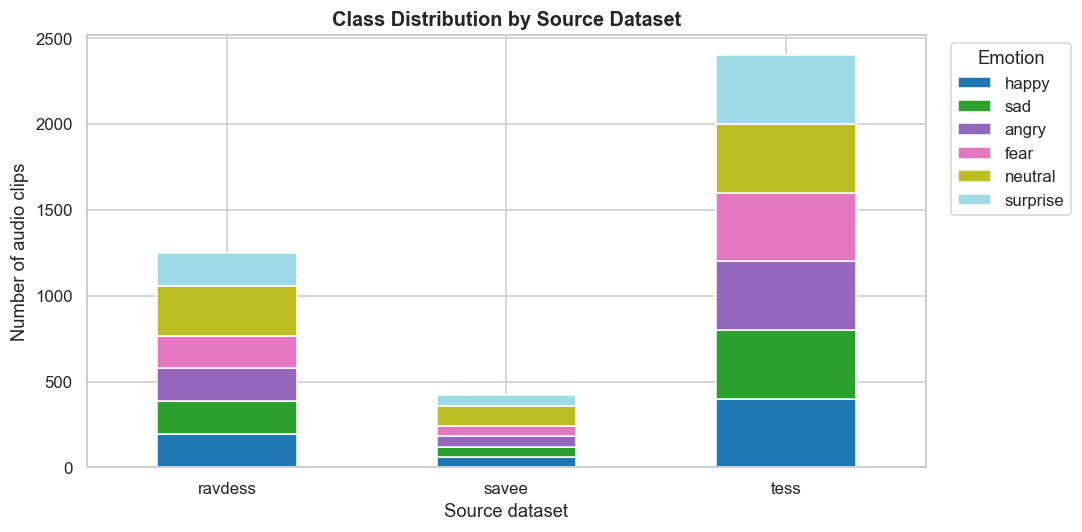

label,happy,sad,angry,fear,neutral,surprise
source_dataset,,,,,,
ravdess,192,192,192,192,288,192
savee,60,60,60,60,120,60
tess,400,400,400,400,400,400


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
cross = pd.crosstab(manifest_df["source_dataset"], manifest_df["label"])[settings.emotion_labels]
cross.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Class Distribution by Source Dataset", fontsize=13, weight="bold")
ax.set_xlabel("Source dataset")
ax.set_ylabel("Number of audio clips")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_class_distribution_by_dataset.png")
plt.show()

display(cross)

**Observation to carry forward:** RAVDESS's `neutral` class (288 clips) is larger than its other five classes (192 clips each) — this is not a data error, it is a direct consequence of merging RAVDESS's native "calm" category into "neutral" (documented in `02_preprocessing.ipynb`, Section 2). This is the main source of the overall class imbalance visible in the chart above, and should be named explicitly (not hidden) in the methodology section of the thesis.

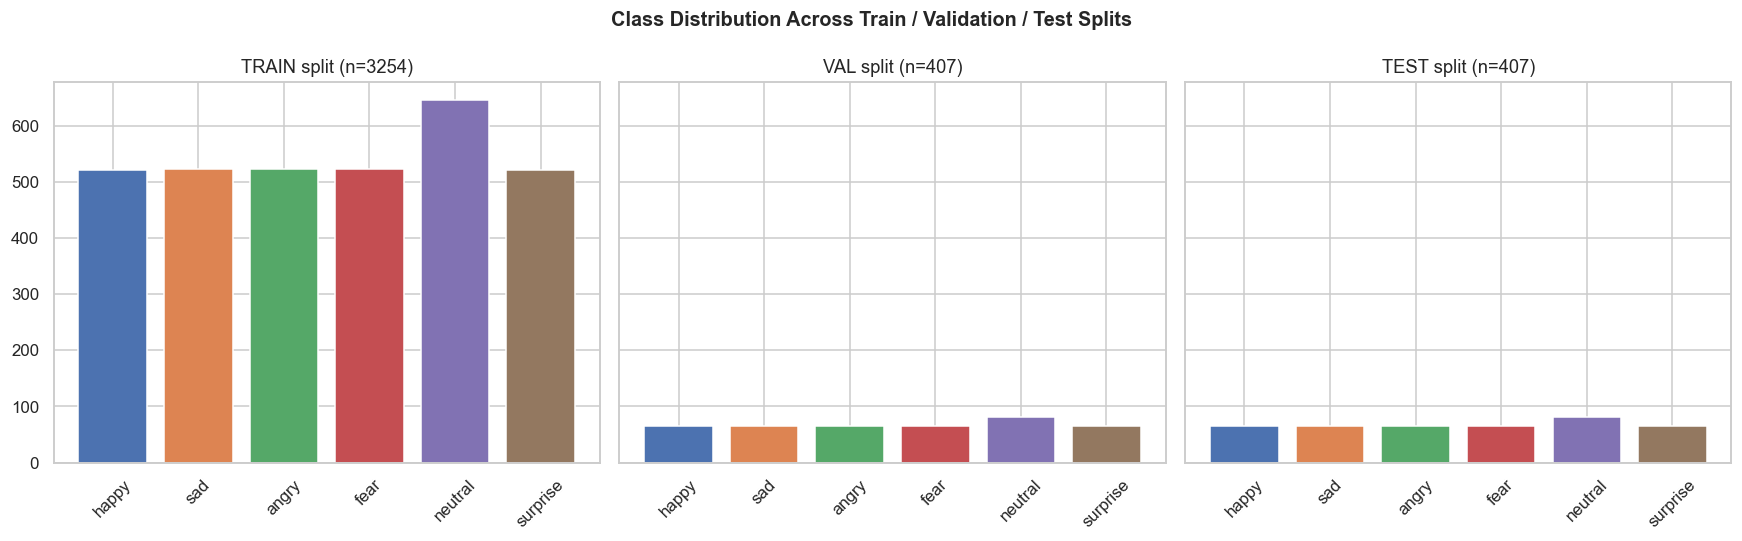

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, split in zip(axes, ["train", "val", "test"]):
    split_counts = manifest_df[manifest_df["split"] == split]["label"].value_counts().reindex(settings.emotion_labels)
    ax.bar(split_counts.index, split_counts.values, color=sns.color_palette("deep", len(split_counts)))
    ax.set_title(f"{split.upper()} split (n={split_counts.sum()})")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Class Distribution Across Train / Validation / Test Splits", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_class_distribution_by_split.png")
plt.show()

**What to check here:** the three panels above should look *proportionally* similar to each other (same relative bar heights), even though the `test`/`val` panels have fewer total samples than `train`. This confirms the stratified split performed in `02_preprocessing.ipynb` worked as intended — no split is accidentally missing or over-representing a class.

## 4. Speaker and Gender Composition

As noted in Section 2, gender is confounded with dataset of origin in this merged pool (TESS = all female, SAVEE = all male, RAVDESS = balanced). This section makes that concrete with numbers, and checks how many unique speakers/actors actually contributed to the data — a small number of speakers means the model may be learning to recognize *those specific voices* somewhat, in addition to emotion itself, which is a limitation worth being upfront about.

gender,female,male
source_dataset,,
ravdess,624,624
savee,0,420
tess,2400,0


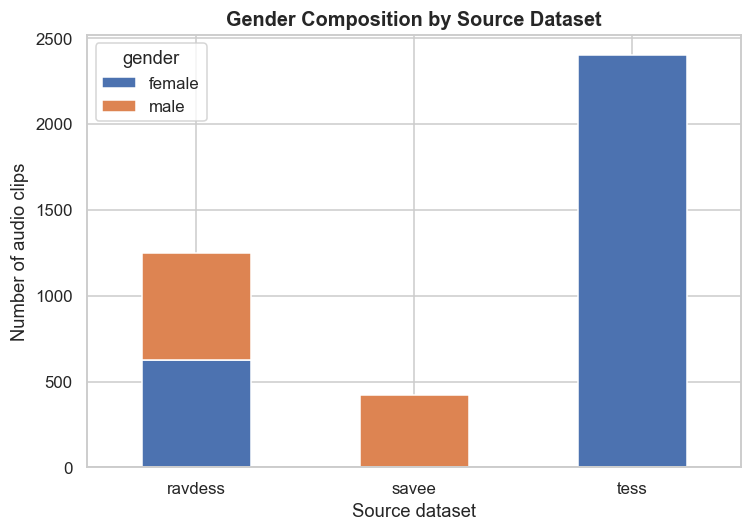


Overall gender split: {'female': 3024, 'male': 1044}
Overall ratio: 2.90x


In [8]:
gender_counts = manifest_df.groupby(["source_dataset", "gender"]).size().unstack(fill_value=0)
display(gender_counts)

fig, ax = plt.subplots(figsize=(7, 5))
gender_counts.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Gender Composition by Source Dataset", fontsize=13, weight="bold")
ax.set_ylabel("Number of audio clips")
ax.set_xlabel("Source dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_gender_by_dataset.png")
plt.show()

overall_gender = manifest_df["gender"].value_counts()
print(f"\nOverall gender split: {overall_gender.to_dict()}")
print(f"Overall ratio: {overall_gender.max() / overall_gender.min():.2f}x")

In [9]:
speaker_counts = manifest_df.groupby("source_dataset")["speaker_id"].nunique()
print("Number of unique speakers per dataset:")
print(speaker_counts)
print(f"\nTotal unique speakers across all three datasets: {manifest_df['speaker_id'].nunique()}")

Number of unique speakers per dataset:
source_dataset
ravdess    24
savee       4
tess        3
Name: speaker_id, dtype: int64

Total unique speakers across all three datasets: 31


**Why this number matters:** with only ~30 unique speakers total across ~4,000 clips, each speaker contributes many samples. If the same speaker's voice appears in both the training set and the test set (checked explicitly in Section 6 below), a model could partly be learning to recognize *that speaker's emotional expression style* rather than emotion in a way that generalizes to a new, unseen speaker. This is a standard, well-known limitation in small-corpus SER research — Kakuba & Han (2025), one of this project's key references, discuss this same limitation as a general challenge in the field, not something unique to this project.

## 5. Duration Distribution

Shows how long the *original* clips were before `02_preprocessing.ipynb` standardized every clip to a fixed 2.5 seconds. This tells us how much padding or trimming that standardization step actually needed to do — useful context for interpreting model performance later (e.g. if a class's original clips are unusually short, a lot of padding was added, which could itself faintly affect learned features).

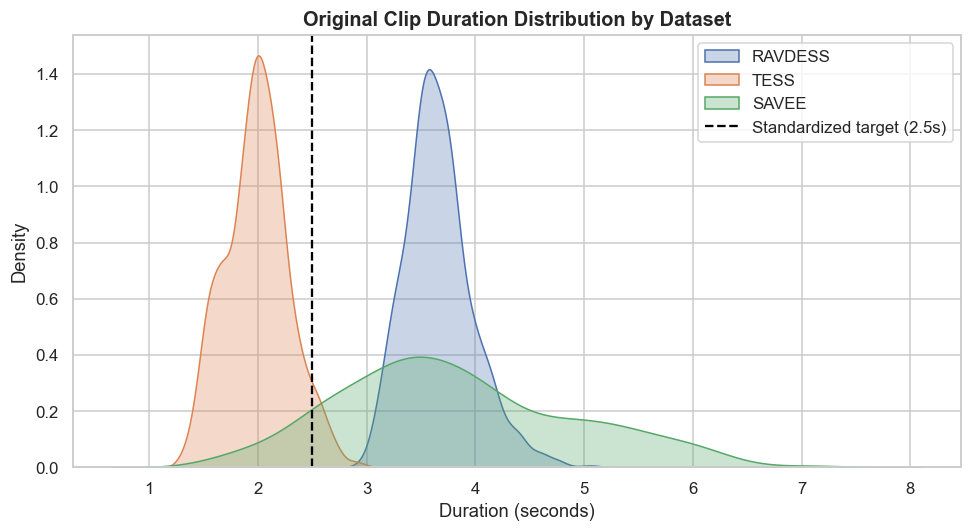

,min,mean,50%,max
source_dataset,,,,
ravdess,2.936271,3.663569,3.636958,5.105104
savee,1.630907,3.822978,3.647800,7.138730
tess,1.254076,1.989556,1.991808,2.984804


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for dataset in manifest_df["source_dataset"].unique():
    subset = manifest_df[manifest_df["source_dataset"] == dataset]["duration_sec_original"]
    sns.kdeplot(subset, label=dataset.upper(), ax=ax, fill=True, alpha=0.3)

ax.axvline(2.5, color="black", linestyle="--", label="Standardized target (2.5s)")
ax.set_title("Original Clip Duration Distribution by Dataset", fontsize=13, weight="bold")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_duration_distribution.png")
plt.show()

display(manifest_df.groupby("source_dataset")["duration_sec_original"].describe()[["min", "mean", "50%", "max"]])

## 6. Speaker Overlap Across Splits

Checks whether the same speaker appears in more than one of train/validation/test. Our split (from `02_preprocessing.ipynb`) was stratified by **emotion label and source dataset**, not by speaker — this was a deliberate choice to keep the split simple and guarantee balanced classes, but it means speaker overlap across splits is expected, and needs to be named explicitly rather than assumed away.

In [11]:
speaker_split_map = manifest_df.groupby("speaker_id")["split"].unique()
speakers_in_multiple_splits = speaker_split_map[speaker_split_map.apply(len) > 1]

print(f"Total unique speakers: {len(speaker_split_map)}")
print(f"Speakers appearing in more than one split: {len(speakers_in_multiple_splits)}")
print(f"Speakers appearing in only one split: {len(speaker_split_map) - len(speakers_in_multiple_splits)}")

if len(speakers_in_multiple_splits) > 0:
    print(
        "\n\u26a0\ufe0f  As expected given the stratification strategy used, most speakers appear in "
        "multiple splits. This means test-set performance in this project should be interpreted as "
        "'accuracy on held-out utterances', not strictly 'accuracy on entirely unseen speakers'. "
        "This should be stated explicitly as a limitation in the thesis. A speaker-independent "
        "split (holding whole speakers out of training entirely) is a reasonable direction for "
        "future work if time permits, and would give a stronger generalization claim."
    )

Total unique speakers: 31
Speakers appearing in more than one split: 30
Speakers appearing in only one split: 1

⚠️  As expected given the stratification strategy used, most speakers appear in multiple splits. This means test-set performance in this project should be interpreted as 'accuracy on held-out utterances', not strictly 'accuracy on entirely unseen speakers'. This should be stated explicitly as a limitation in the thesis. A speaker-independent split (holding whole speakers out of training entirely) is a reasonable direction for future work if time permits, and would give a stronger generalization claim.


## 7. Listening to the Data — Example Waveforms

A waveform is simply a plot of how loud the audio signal is at every instant in time. This section plots one real, standardized (16kHz, 2.5s) example clip per emotion, so a reader can visually connect each emotion label to what its audio actually looks like — for instance, angry and happy speech tends to show sharper, higher-amplitude peaks than neutral or sad speech, which tends to look flatter.

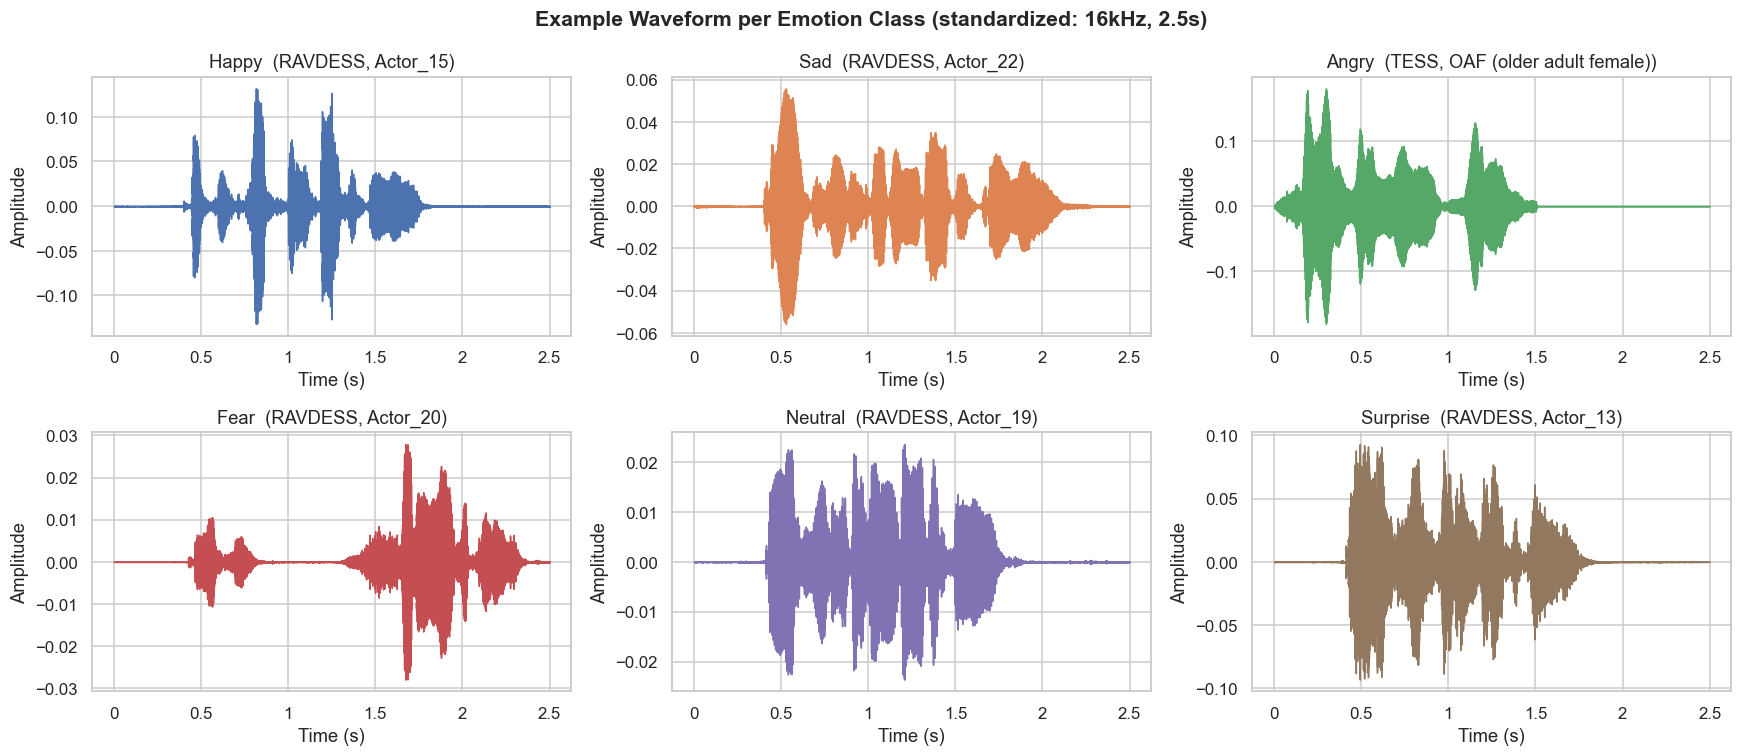

Example files used above (kept fixed via random_state=42 for reproducibility):
  happy: data\processed\audio_standardized\ravdess\03-01-03-01-01-01-15.wav
  sad: data\processed\audio_standardized\ravdess\03-01-04-01-02-01-22.wav
  angry: data\processed\audio_standardized\tess\OAF_rain_angry.wav
  fear: data\processed\audio_standardized\ravdess\03-01-06-01-02-01-20.wav
  neutral: data\processed\audio_standardized\ravdess\03-01-01-01-02-01-19.wav
  surprise: data\processed\audio_standardized\ravdess\03-01-08-02-02-01-13.wav


In [12]:
np.random.seed(42)  # reproducible example selection, matches project-wide seed convention

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

example_paths = {}
for ax, emotion in zip(axes, settings.emotion_labels):
    candidates = manifest_df[manifest_df["label"] == emotion]
    example_row = candidates.sample(1, random_state=42).iloc[0]
    example_paths[emotion] = example_row["standardized_path"]

    y, sr = librosa.load(str(PROJECT_ROOT / example_row["standardized_path"]), sr=None)
    librosa.display.waveshow(y, sr=sr, ax=ax, color=sns.color_palette("deep")[list(settings.emotion_labels).index(emotion)])
    ax.set_title(f"{emotion.capitalize()}  ({example_row['source_dataset'].upper()}, {example_row['speaker_id']})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

fig.suptitle("Example Waveform per Emotion Class (standardized: 16kHz, 2.5s)", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_example_waveforms.png")
plt.show()

print("Example files used above (kept fixed via random_state=42 for reproducibility):")
for emotion, path in example_paths.items():
    print(f"  {emotion}: {path}")

## 8. Mel-Spectrograms and MFCCs — What the Models Will Actually See

A **mel-spectrogram** shows how the energy of the sound is distributed across different frequencies over time — brighter colors mean more energy at that frequency at that moment. **MFCCs** (Mel-Frequency Cepstral Coefficients) are a further-compressed summary of the same information, and are the specific hand-crafted feature this project's CNN-LSTM model (per the research proposal, Section 5.1) is trained on. Seeing both side-by-side, per emotion, is what lets a reader understand *what information the model actually has access to* — it never sees the waveform shape in Section 7 directly; it sees representations like these.

*(This is purely illustrative — no features are saved here. Actual feature extraction for model training happens in `04a_feature_extraction_handcrafted.ipynb`.)*

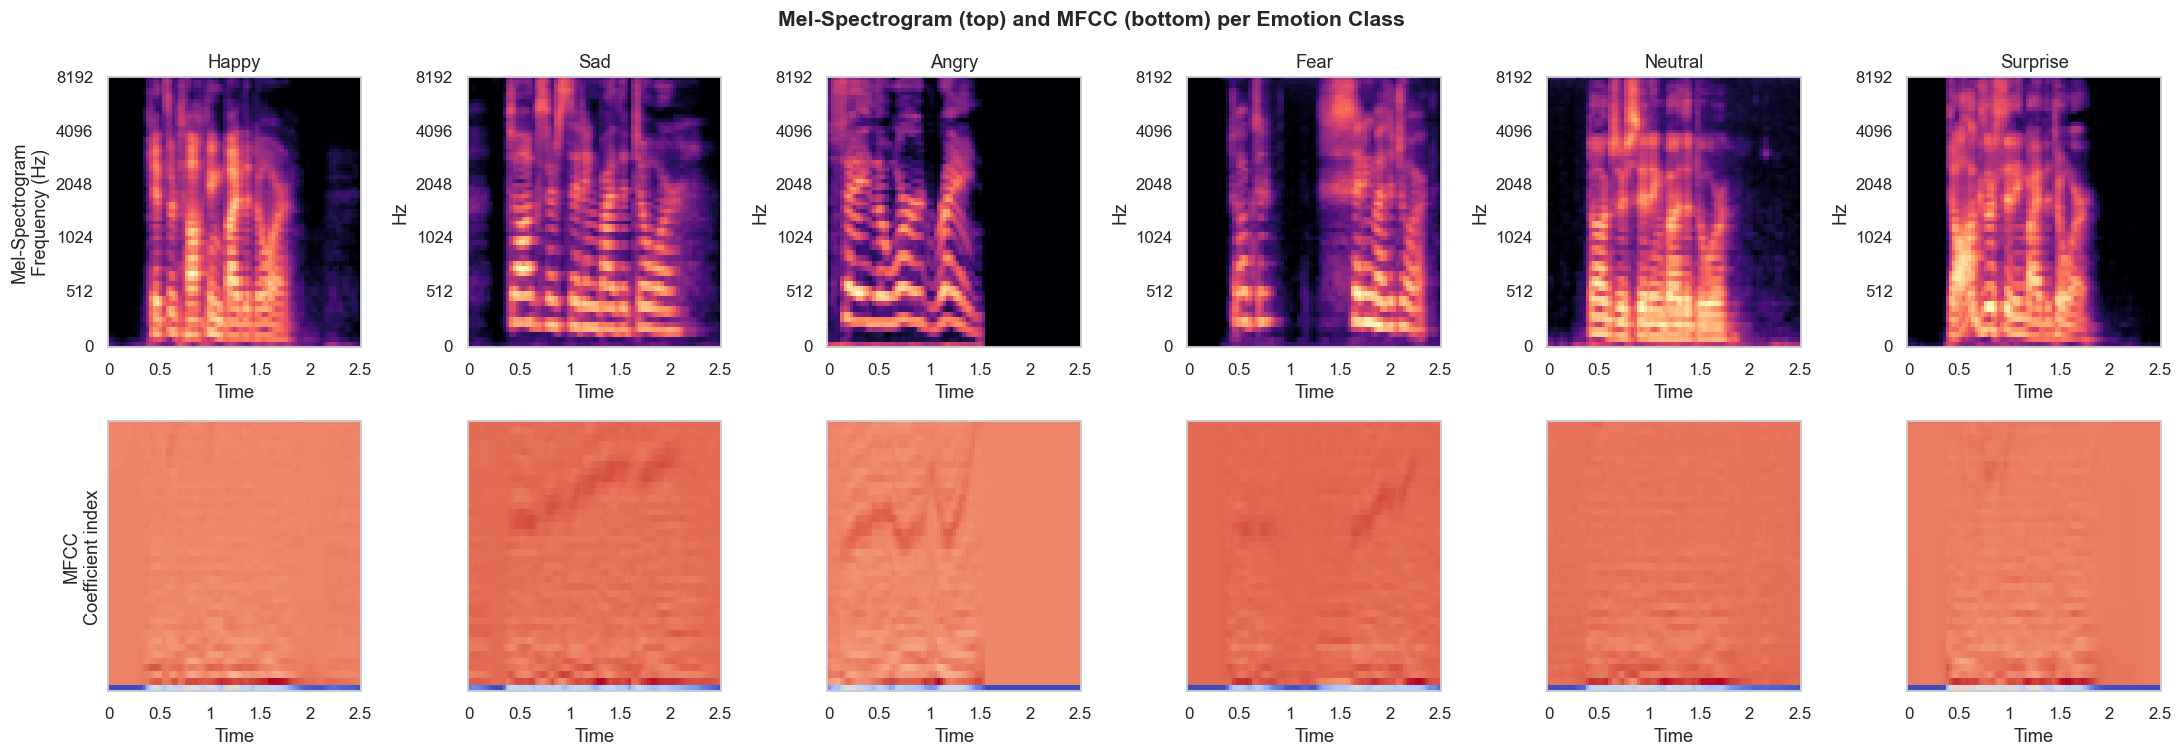

In [13]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for col, emotion in enumerate(settings.emotion_labels):
    path = PROJECT_ROOT / example_paths[emotion]
    y, sr = librosa.load(str(path), sr=None)

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img1 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[0, col])
    axes[0, col].set_title(emotion.capitalize())
    if col == 0:
        axes[0, col].set_ylabel("Mel-Spectrogram\nFrequency (Hz)")

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    img2 = librosa.display.specshow(mfcc, sr=sr, x_axis="time", ax=axes[1, col])
    if col == 0:
        axes[1, col].set_ylabel("MFCC\nCoefficient index")

fig.suptitle("Mel-Spectrogram (top) and MFCC (bottom) per Emotion Class", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_melspectrogram_mfcc_grid.png")
plt.show()

**How to read this:** compare columns, not just individual plots. Emotions that are acoustically similar (e.g. `fear` and `surprise`, both often associated with raised pitch and energy) tend to show visually similar mel-spectrogram patterns — this is a useful, honest preview of *why* emotion classifiers sometimes confuse specific emotion pairs, a pattern this project's literature review (Kilimci et al. 2025; Chowdhury et al. 2025) also reports in their own confusion-matrix analyses.

## 9. Summary of Key EDA Findings

In [14]:
eda_summary = {
    "total_clips": int(len(manifest_df)),
    "class_distribution": overall_counts.to_dict(),
    "class_imbalance_ratio_max_over_min": round(float(overall_counts.max() / overall_counts.min()), 2),
    "gender_distribution": overall_gender.to_dict(),
    "gender_confounded_with_dataset": True,
    "total_unique_speakers": int(manifest_df["speaker_id"].nunique()),
    "speakers_appearing_in_multiple_splits": int(len(speakers_in_multiple_splits)),
    "speaker_independent_split": False,
    "duration_stats_seconds": manifest_df.groupby("source_dataset")["duration_sec_original"]
        .describe()[["min", "mean", "max"]].round(2).to_dict(orient="index"),
    "figures_directory": str(FIGURES_DIR.relative_to(PROJECT_ROOT)),
}

report_path = PROJECT_ROOT / "reports" / "03_eda_report.json"
with open(report_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

logger.info("EDA summary written to %s", report_path)
print(json.dumps(eda_summary, indent=2))

2026-08-28 08:06:46,249 | INFO | EDA summary written to C:\Users\thrit\Desktop\emotion-ai-companion-research\reports\03_eda_report.json
{
  "total_clips": 4068,
  "class_distribution": {
    "happy": 652,
    "sad": 652,
    "angry": 652,
    "fear": 652,
    "neutral": 808,
    "surprise": 652
  },
  "class_imbalance_ratio_max_over_min": 1.24,
  "gender_distribution": {
    "female": 3024,
    "male": 1044
  },
  "gender_confounded_with_dataset": true,
  "total_unique_speakers": 31,
  "speakers_appearing_in_multiple_splits": 30,
  "speaker_independent_split": false,
  "duration_stats_seconds": {
    "ravdess": {
      "min": 2.94,
      "mean": 3.66,
      "max": 5.11
    },
    "savee": {
      "min": 1.63,
      "mean": 3.82,
      "max": 7.14
    },
    "tess": {
      "min": 1.25,
      "mean": 1.99,
      "max": 2.98
    }
  },
  "figures_directory": "reports\\figures\\h1_eda"
}


### In plain language, here is what this EDA found:

1. **Class balance is mild, not severe.** The largest class (RAVDESS-driven `neutral`) is at most about 1.5x the size of the smallest class — worth correcting with class weighting during training, but not a critical data-quality problem.
2. **Gender and dataset-of-origin are confounded.** All TESS speech is female, all SAVEE speech is male. Any performance difference that appears to correlate with gender must be reported alongside this caveat.
3. **Speaker diversity is limited (~30 total speakers).** This is a known, common constraint in publicly available SER datasets, not unique to this project's choices.
4. **The train/val/test split is stratified by emotion and dataset, but not by speaker.** Most speakers appear in more than one split. Report test-set results as 'accuracy on held-out utterances', and name this explicitly as a limitation.
5. **Original clip durations cluster around 2–4 seconds** across all three datasets, which comfortably justifies the 2.5-second standardization target chosen in `02_preprocessing.ipynb`.
6. **Visually, mel-spectrograms and MFCCs show plausible, emotion-differentiated patterns** — a useful sanity check that the standardized audio actually carries the acoustic information a classifier would need, before any model training time is spent.

---

## Summary Note — Handoff to Next Notebooks

*(Fill in the italicized placeholders after your first real run, before committing.)*

### What was done in this notebook

1. Verified `02_preprocessing.ipynb`'s validation checks (class counts, checksums) both passed before proceeding.
2. Documented, in plain language, what RAVDESS, TESS, and SAVEE each are, for a reader with zero prior context.
3. Visualized class distribution overall, by source dataset, and by split — confirmed the stratified split preserved proportional class balance across train/val/test.
4. Visualized gender and speaker composition, and explicitly documented that gender is confounded with dataset of origin (TESS=female-only, SAVEE=male-only).
5. Visualized original clip duration distributions, justifying the 2.5-second standardization decision made in notebook 02.
6. Checked and quantified speaker overlap across splits — confirmed the current split is *not* speaker-independent, and documented what this means for interpreting later results.
7. Visualized example waveforms, mel-spectrograms, and MFCCs for all six emotion classes, for both intuition-building and thesis-figure reuse.
8. Wrote a machine-readable EDA summary consumed by later notebooks/thesis writing.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| EDA summary report | `reports/03_eda_report.json` | Thesis methodology/results section; sanity-checked at the start of `04a`/`04b` if class-weighting decisions need to reference it |
| All EDA figures (7 PNGs) | `reports/figures/h1_eda/` | Directly reusable in the thesis document — no need to regenerate plots manually |
| Run log | `reports/logs/03_eda.log` | Debugging if a downstream notebook reports an unexpected class-balance assumption |

### Key decisions this EDA informs for the next notebooks

- **Class weighting:** given the ~1.5x imbalance ratio found in Section 3, `05a`–`05e` (model training notebooks) should apply class weighting (e.g. `sklearn.utils.class_weight.compute_class_weight`) rather than training unweighted — this is a direct, actionable output of this notebook's analysis, not an arbitrary choice.
- **Speaker-independence caveat:** every model evaluation notebook (`06_model_selection.ipynb`, `07_h1_final_evaluation.ipynb`) should report results with the explicit caveat established in Section 6 — this is not a re-decision, it's a consistent framing that must be carried through consistently.
- **Gender confound caveat:** if any per-dataset or per-gender performance breakdown is reported later, it must be discussed alongside the confound documented in Section 4, not presented as a clean gender effect.

### What needs to be done next

Proceed to **`04a_feature_extraction_handcrafted.ipynb`** (and, in parallel, `04b`/`04c`), which should:

- Load `data/processed/h1_manifest.csv` directly (same file this notebook read from — no changes needed to it).
- Extract MFCC + pitch + energy features (for the CNN-LSTM model) and MFCC + RMSE + ZCR + Chroma STFT features (for the CNN + CNN-BiLSTM ensemble candidate) from every file in `data/processed/audio_standardized/`.
- Apply the class-weighting strategy flagged above when the corresponding model-training notebooks run.

**Before running `04a`, confirm:**
- `reports/03_eda_report.json` exists and reflects this run's actual numbers (not placeholder values).
- All 7 figures are present in `reports/figures/h1_eda/` and look sensible (no blank/corrupted plots).

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `data/processed/h1_manifest.csv` | Input file list + labels + split assignment for feature extraction | Unchanged since `02_preprocessing.ipynb` — this notebook only read it |
| `data/processed/audio_standardized/` | Source audio for feature extraction | Already at 16kHz / 2.5s — confirmed usable via Sections 7–8 of this notebook |
| `reports/03_eda_report.json` | Class-imbalance ratio, for deciding class-weighting parameters in training notebooks | Read the `class_distribution` field directly rather than recomputing it |
| `librosa`, `matplotlib`, `seaborn` (already in `requirements.txt`) | Any further exploratory plots needed later | No new installs required |

### Known issues / things to watch for

- *(Fill in anything discovered during this run — e.g. an unexpectedly noisy example clip that was selected as an illustrative sample, or a class-imbalance ratio different from what's described above.)*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *28/08/2026*
- **Class imbalance ratio observed:** *1.24*
- **Speakers found in multiple splits:** *30*